In [1]:
import cartopy.crs as crs 
import matplotlib.pyplot as plt
import numpy as np
from cartopy.io.img_tiles import GoogleTiles
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter


In [2]:
lat = -2 
lon = 147
project = 'Manus'

/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


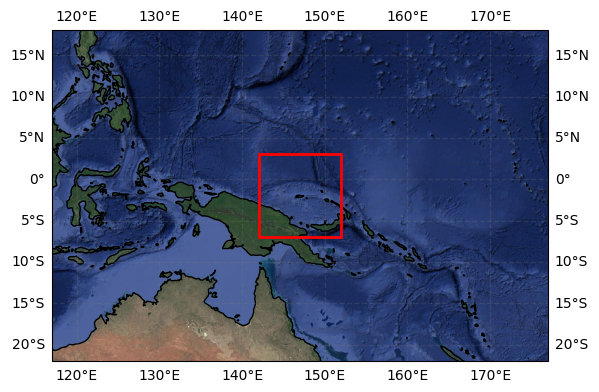

In [3]:
fig,ax = plt.subplots(subplot_kw={'projection': crs.PlateCarree()})

ax.coastlines(zorder=2)

ax.set_extent([lon-30, lon+30, lat-20, lat+20], crs=crs.PlateCarree())

tiler = GoogleTiles(style='satellite')

ax.add_image(tiler, 5,zorder=0)
# add rectangle
rect_extent = [lon-5, lon+5, lat-5, lat+5]
ax.add_patch(plt.Rectangle((rect_extent[0], rect_extent[2]), 
                            rect_extent[1]-rect_extent[0], 
                            rect_extent[3]-rect_extent[2],
                            linewidth=2, edgecolor='red', facecolor='none', zorder=3))


gl = ax.gridlines(draw_labels=True,linewidth=1, color='gray', alpha=0.2, linestyle='--')

gl.yformatter = LatitudeFormatter()
gl.xformatter = LongitudeFormatter()


out_fol= '/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/plots/'

fig.savefig(f'{out_fol}{project}_figure1.png',dpi=300)


In [5]:
import xarray as xr 
import pandas as pd 
import glob 

In [6]:
dir_main = '/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/Datasets/twpmetC1.b1/'


dset_all = xr.open_mfdataset(dir_main+'*.cdf',combine='by_coords')

/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
module 'cfgrib.messages' has no attribute 'DEFAULT_INDEXPATH'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/var/folders/bt/kswp83jx5mj4bn1bjkh9g4rsg_b7ks/T/ipykernel_1299/3227979964.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  dset_all = xr.open_mfdataset(dir_main+'*.cdf',combine='by_coords')


In [7]:
dset_all

<xarray.Dataset> Size: 88MB
Dimensions:                       (time: 308160)
Coordinates:
  * time                          (time) datetime64[ns] 2MB 2011-10-01 ... 20...
Data variables: (12/61)
    base_time                     (time) datetime64[ns] 2MB 2011-10-01 ... 20...
    time_offset                   (time) datetime64[ns] 2MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_time                       (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    atmos_pressure                (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_atmos_pressure             (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    temp_mean                     (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    ...                            ...
    qc_logger_volt                (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    logger_temp                   (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_logger_temp                (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                           (time) float32 1MB -2.06 -2.06 ... -2.06 -2.06
    lon                           (time) float32 1MB 147.4 147.4 ... 147.4 147.4
    alt                           (time) float32 1MB 4.0 4.0 4.0 ... 4.0 4.0 4.0
Attributes: (12/31)
    command_line:                met_ingest -s twp -f C1
    process_version:             ingest-met-4.6-0.el5
    dod_version:                 met-b1-3.2
    site_id:                     twp
    facility_id:                 C1: Momote, Manus Island
    data_level:                  b1
    ...                          ...
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    zeb_platform:                twpmetC1.b1
    history:                     created by user dsmgr on machine gold at 1-O...

In [8]:
dset_sub = dset_all[['temp_mean','rh_mean','atmos_pressure','org_precip_rate_mean',
                     'wspd_arith_mean','wdir_vec_mean']]



dset_sub_hourly = dset_sub.resample(time='1h').mean().compute()


In [9]:
dset_sub_hourly['atmos_pressure'] = dset_sub_hourly['atmos_pressure'] * 10  # convert to hPa

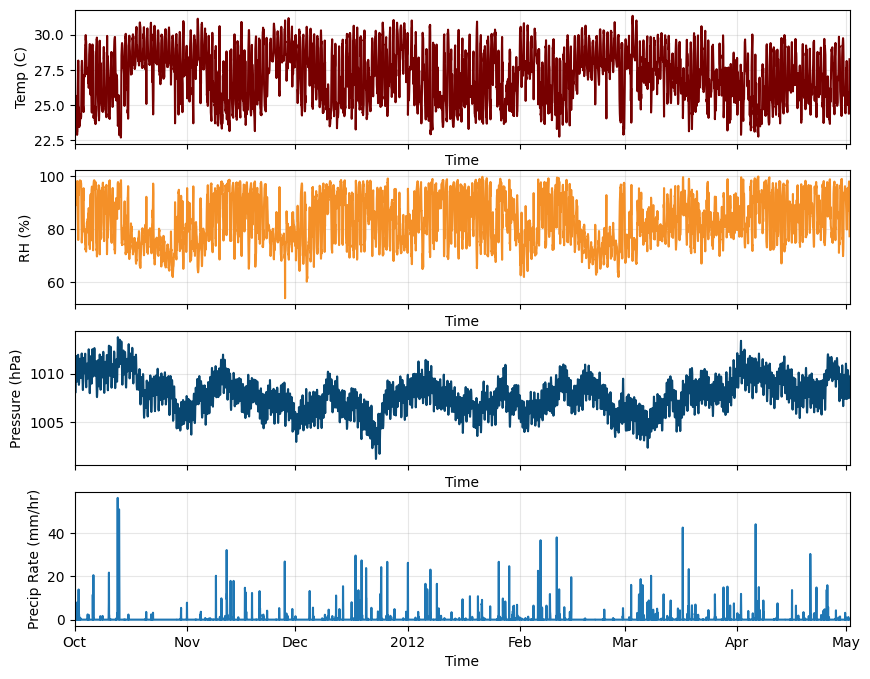

In [10]:
fig,ax = plt.subplots(4,1,figsize=(10,8),sharex=True,sharey=False)

dset_sub_hourly['temp_mean'].plot(ax=ax[0],color='#770000')

dset_sub_hourly['rh_mean'].plot(ax=ax[1],color='#f49028')

dset_sub_hourly['atmos_pressure'].plot(ax=ax[2],color='#084771')

dset_sub_hourly['org_precip_rate_mean'].plot(ax=ax[3],color='#1f77b4')

ax[0].set_ylabel('Temp (C)')
ax[1].set_ylabel('RH (%)')
ax[2].set_ylabel('Pressure (hPa)')
ax[3].set_ylabel('Precip Rate (mm/hr)')

for a in ax:
    a.set_xlabel('Time')
    a.grid(True,alpha=0.3)
    a.set_xlim(dset_sub_hourly['time'].values[0],dset_sub_hourly['time'].values[-1])

#fig.savefig(f'{out_fol}{project}_figure2_timeseries_arm_met.png',dpi=300)


In [40]:
dset_sub_hourly.compute()

<xarray.Dataset> Size: 164kB
Dimensions:               (time: 5136)
Coordinates:
  * time                  (time) datetime64[ns] 41kB 2011-10-01 ... 2012-05-0...
Data variables:
    temp_mean             (time) float32 21kB 26.94 28.1 28.07 ... 27.82 28.26
    rh_mean               (time) float32 21kB 85.33 79.05 78.33 ... 79.69 77.39
    atmos_pressure        (time) float32 21kB 1.011e+03 1.01e+03 ... 1.01e+03
    org_precip_rate_mean  (time) float32 21kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    wspd_arith_mean       (time) float32 21kB 1.127 1.253 1.137 ... 1.083 1.314
    wdir_vec_mean         (time) float32 21kB 174.4 99.66 85.97 ... 67.38 74.36
Attributes: (12/31)
    command_line:                met_ingest -s twp -f C1
    process_version:             ingest-met-4.6-0.el5
    dod_version:                 met-b1-3.2
    site_id:                     twp
    facility_id:                 C1: Momote, Manus Island
    data_level:                  b1
    ...                          ...
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    zeb_platform:                twpmetC1.b1
    history:                     created by user dsmgr on machine gold at 1-O...

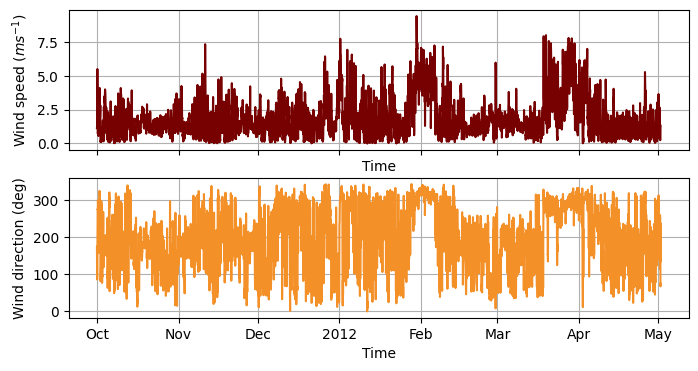

In [15]:
fig,ax = plt.subplots(2,1,figsize=(8,4),sharex=True)

dset_sub_hourly['wspd_arith_mean'].plot(ax=ax[0],color='#770000')

dset_sub_hourly['wdir_vec_mean'].plot(ax=ax[1],color='#f49028')

ax[0].set_ylabel('Wind speed ($ms^{-1}$)')

ax[1].set_ylabel('Wind direction (deg)')

for axx in ax:
    axx.set_xlabel('Time')
    axx.grid()
    a.set_xlim(dset_sub_hourly['time'].values[0],dset_sub_hourly['time'].values[-1])

#fig.savefig(f'{out_fol}__figure3_timeseries_arm_met.png')

## Diurnal plots (time series)

In [16]:
dset_sub_hourly_local = dset_sub_hourly.shift(time=10)

dset_sub_hourly_local.compute()

<xarray.Dataset> Size: 164kB
Dimensions:               (time: 5136)
Coordinates:
  * time                  (time) datetime64[ns] 41kB 2011-10-01 ... 2012-05-0...
Data variables:
    temp_mean             (time) float32 21kB nan nan nan ... 25.35 25.02 25.35
    rh_mean               (time) float32 21kB nan nan nan ... 92.78 95.66 92.43
    atmos_pressure        (time) float32 21kB nan nan nan ... 1.01e+03 1.01e+03
    org_precip_rate_mean  (time) float32 21kB nan nan nan nan ... 0.0 0.0 0.0
    wspd_arith_mean       (time) float32 21kB nan nan nan ... 0.481 0.3547 2.677
    wdir_vec_mean         (time) float32 21kB nan nan nan ... 212.9 177.2 211.0
Attributes: (12/31)
    command_line:                met_ingest -s twp -f C1
    process_version:             ingest-met-4.6-0.el5
    dod_version:                 met-b1-3.2
    site_id:                     twp
    facility_id:                 C1: Momote, Manus Island
    data_level:                  b1
    ...                          ...
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    zeb_platform:                twpmetC1.b1
    history:                     created by user dsmgr on machine gold at 1-O...

In [17]:
dset_sub_hourly_diurnal = dset_sub_hourly_local.groupby('time.hour').mean().compute()

NameError: name 'out_fol' is not defined

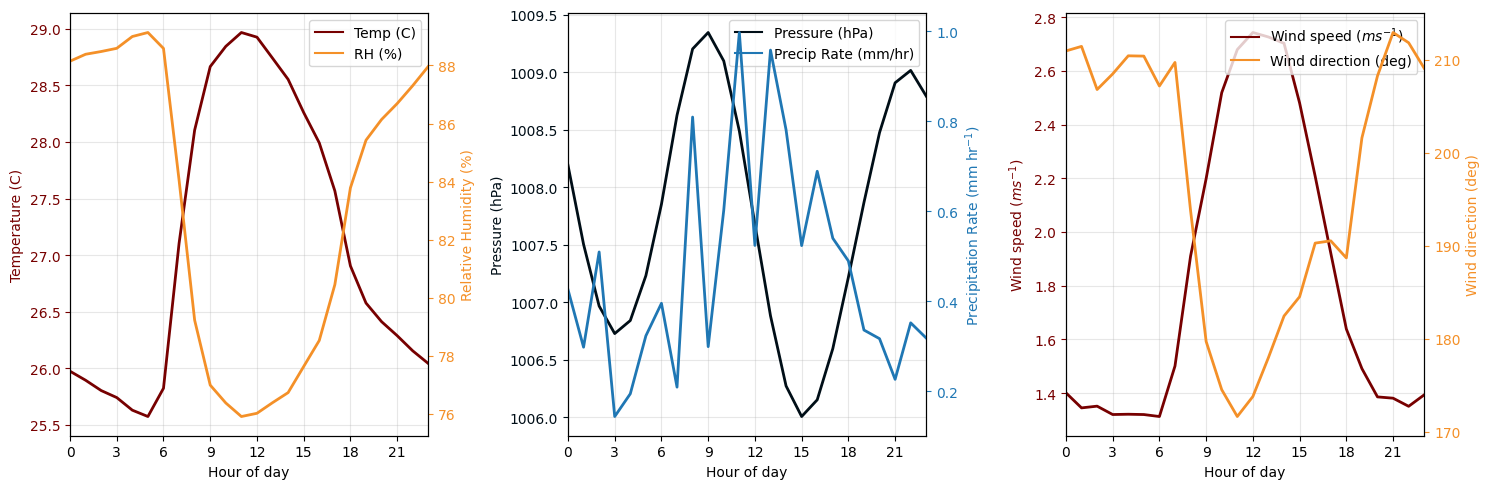

In [18]:
import matplotlib as mpl

fig,ax = plt.subplots(1,3,figsize=(15,5))
dset_sub_hourly_diurnal['temp_mean'].plot(ax=ax[0],color='#770000',linewidth=2)
ax2 = ax[0].twinx()
dset_sub_hourly_diurnal['rh_mean'].plot(ax=ax2,color='#f49028',linewidth=2)
legend_elem=mpl.lines.Line2D([], [], color='#770000', label='Temp (C)')
legend_elem2=mpl.lines.Line2D([], [], color='#f49028', label='RH (%)')
ax[0].legend(handles=[legend_elem,legend_elem2],loc='upper right')
ax[0].set_ylabel('Temperature (C)')
ax2.set_ylabel('Relative Humidity (%)')
#add custom colors for the y axis including labels and ticks

ax[0].yaxis.label.set_color('#770000')
ax[0].tick_params(axis='y', colors='#770000')
ax2.tick_params(axis='y', colors='#f49028')
ax2.yaxis.label.set_color('#f49028')




dset_sub_hourly_diurnal['atmos_pressure'].plot(ax=ax[1],color="#000E17",linewidth=2)
ax3 = ax[1].twinx()
dset_sub_hourly_diurnal['org_precip_rate_mean'].plot(ax=ax3,color='#1f77b4',linewidth=2)
legend_elem3=mpl.lines.Line2D([], [], color='#000E17', label='Pressure (hPa)')
legend_elem4=mpl.lines.Line2D([], [], color='#1f77b4', label='Precip Rate (mm/hr)')
ax[1].legend(handles=[legend_elem3,legend_elem4])
ax[1].set_ylabel('Pressure (hPa)')
ax3.set_ylabel('Precipitation Rate (mm hr$^{-1}$)')
ax[1].yaxis.label.set_color('#000E17')
ax[1].tick_params(axis='y', colors='#000E17')
ax3.tick_params(axis='y', colors='#1f77b4')
ax3.yaxis.label.set_color('#1f77b4')    



dset_sub_hourly_diurnal['wspd_arith_mean'].plot(ax=ax[2],color='#770000',linewidth=2)
ax4 = ax[2].twinx()
dset_sub_hourly_diurnal['wdir_vec_mean'].plot(ax=ax4,color='#f49028',linewidth=2)   
legend_elem5=mpl.lines.Line2D([], [], color='#770000', label='Wind speed ($ms^{-1}$)')
legend_elem6=mpl.lines.Line2D([], [], color='#f49028', label='Wind direction (deg)')
ax[2].legend(handles=[legend_elem5,legend_elem6],loc='upper right') 
ax[2].set_ylabel('Wind speed ($ms^{-1}$)')
ax4.set_ylabel('Wind direction (deg)')
ax[2].yaxis.label.set_color('#770000')
ax[2].tick_params(axis='y', colors='#770000')
ax4.tick_params(axis='y', colors='#f49028')
ax4.yaxis.label.set_color('#f49028')    

for axx in ax:
    axx.set_xlabel('Hour of day')
    axx.grid(True,alpha=0.3)
    axx.set_xlim(0,23)
    axx.set_xticks(np.arange(0,24,3))

fig.tight_layout()

fig.savefig(f'{out_fol}{project}_figure4_arm_met_diurnal.png',dpi=300)

In [99]:
arm_interp_dir = '/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/Datasets/twpinterpolatedsondeC1.c1/'


dset_interp = xr.open_mfdataset(arm_interp_dir+'*.nc',combine='by_coords')

/var/folders/bt/kswp83jx5mj4bn1bjkh9g4rsg_b7ks/T/ipykernel_60710/3279465751.py:4: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  dset_interp = xr.open_mfdataset(arm_interp_dir+'*.nc',combine='by_coords')


In [100]:
dset_interp

<xarray.Dataset> Size: 15GB
Dimensions:            (time: 306720, height: 332)
Coordinates:
  * time               (time) datetime64[ns] 2MB 2011-10-01T00:00:30 ... 2012...
  * height             (height) float32 1kB 0.004 0.024 0.044 ... 39.5 40.0 40.5
Data variables: (12/39)
    base_time          (time) datetime64[ns] 2MB 2011-10-01 ... 2012-04-30
    time_offset        (time) datetime64[ns] 2MB dask.array<chunksize=(1440,), meta=np.ndarray>
    precip             (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_precip          (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    temp               (time, height) float32 407MB dask.array<chunksize=(1440, 332), meta=np.ndarray>
    qc_temp            (time, height) int32 407MB dask.array<chunksize=(1440, 332), meta=np.ndarray>
    ...                 ...
    qc_rh_scaled       (time, height) int32 407MB dask.array<chunksize=(1440, 332), meta=np.ndarray>
    aqc_rh_scaled      (time, height) int32 407MB dask.array<chunksize=(1440, 332), meta=np.ndarray>
    vapor_source       (time, height) int32 407MB dask.array<chunksize=(1440, 332), meta=np.ndarray>
    lat                (time) float32 1MB -2.06 -2.06 -2.06 ... -2.06 -2.06
    lon                (time) float32 1MB 147.4 147.4 147.4 ... 147.4 147.4
    alt                (time) float32 1MB 4.0 4.0 4.0 4.0 ... 4.0 4.0 4.0 4.0
Attributes: (12/13)
    command_line:          idl -D 0 -R -n interpolatedsonde -s twp -f C1 -b 2...
    Conventions:           ARM-1.1
    process_version:       vap-interpolatedsonde-6.6-0.el6
    input_datastreams:     twpgriddedsondeC1.c0 : 2.2 : 20110929.000030-20111...
    dod_version:           interpolatedsonde-c1-4.0
    site_id:               twp
    ...                    ...
    facility_id:           C1
    data_level:            c1
    location_description:  Tropical Western Pacific (TWP), Manus Island, Papu...
    datastream:            twpinterpolatedsondeC1.c1
    doi:                   10.5439/1095316
    history:               created by user ttoto on machine silver at 2016-05...

In [12]:
dset_interp_hourly = dset_interp[['temp','sh','wspd','wdir','bar_pres']].resample(time='1h').mean().compute()
dset_interp_hourly


NameError: name 'dset_interp' is not defined

In [106]:
dset_interp_hourly_local = dset_interp_hourly.shift(time=10)

dset_interp_hourly_local_diurnal = dset_interp_hourly_local.groupby('time.hour').mean().compute()

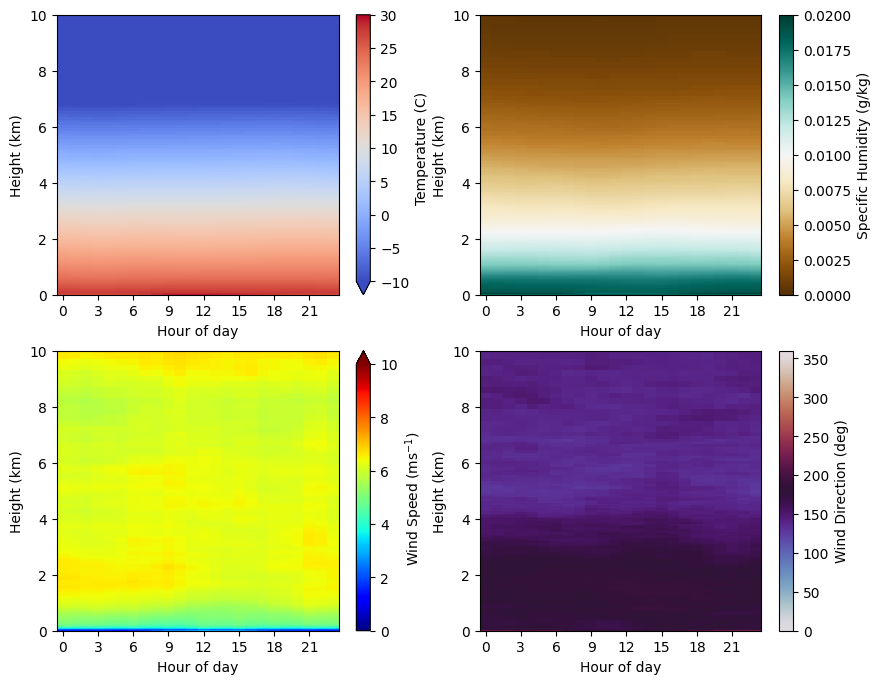

In [135]:
fig,ax = plt.subplots(2,2,figsize=(10,8))


dset_interp_hourly_local_diurnal['temp'].plot(ax=ax[0,0],x='hour',cbar_kwargs={'label':'Temperature (C)'},
                                              vmin=-10,vmax=30,cmap='coolwarm')
ax[0,0].set_ylabel('Height (km)')
ax[0,0].set_ylim(0,10)

dset_interp_hourly_local_diurnal['sh'].plot(ax=ax[0,1],x='hour',cbar_kwargs={'label':'Specific Humidity (g/kg)'},
                                            cmap='BrBG',vmin=0,vmax=0.02)
ax[0,1].set_ylabel('Height (km)')
ax[0,1].set_ylim(0,10)

dset_interp_hourly_local_diurnal['wspd'].plot(ax=ax[1,0],x='hour',cbar_kwargs={'label':'Wind Speed (ms$^{-1}$)'},
                                              cmap='jet',vmin=0,vmax=10)
ax[1,0].set_ylabel('Height (km)')
ax[1,0].set_ylim(0,10)

dset_interp_hourly_local_diurnal['wdir'].plot(ax=ax[1,1],x='hour',cbar_kwargs={'label':'Wind Direction (deg)'},
                                                cmap='twilight',vmin=0,vmax=360)
ax[1,1].set_ylabel('Height (km)')
ax[1,1].set_ylim(0,10)
for axx in ax.flat:
    axx.set_xlabel('Hour of day')
    axx.set_xticks(np.arange(0,24,3))

fig.savefig(f'{out_fol}{project}_figure5_arm_interp_diurnal.png',dpi=300)

In [19]:
dset_sub_hourly_frame = dset_sub_hourly[['wdir_vec_mean','wspd_arith_mean']].to_dataframe()



In [60]:
dset_sub_hourly_frame

,wdir_vec_mean,wspd_arith_mean
time,,
2011-10-01 00:00:00,174.426987,1.126783
2011-10-01 01:00:00,99.661339,1.252617
2011-10-01 02:00:00,85.971489,1.136750
2011-10-01 03:00:00,105.280846,1.202233
2011-10-01 04:00:00,162.240005,5.515033
...,...,...
2012-05-01 19:00:00,253.773300,0.382550
2012-05-01 20:00:00,132.493134,0.235767
2012-05-01 21:00:00,238.705154,1.032833


In [105]:
mean_morning_winds = dset_sub_hourly_diurnal.sel(hour=slice(6,11)).to_dataframe()[['wspd_arith_mean','wdir_vec_mean']]

mean_evening_winds = dset_sub_hourly_diurnal.sel(hour=slice(13,17)).to_dataframe()[['wspd_arith_mean','wdir_vec_mean']]

In [61]:
nfreq

,direction,proportion
11,0,0.194704
10,30,2.044393
9,90,6.639408
8,330,6.795171
7,120,7.281931
6,60,7.476636
5,270,8.411215
4,240,10.221963
3,150,11.779595
2,300,12.655763


In [106]:
mean_morning_winds

,wspd_arith_mean,wdir_vec_mean
hour,,
6,1.313036,207.199051
7,1.501004,209.736252
8,1.910054,193.790695
9,2.198703,179.692780
10,2.518565,174.501511
11,2.679124,171.613388


In [107]:
mean_evening_winds

,wspd_arith_mean,wdir_vec_mean
hour,,
13,2.725965,177.963669
14,2.702444,182.433350
15,2.480360,184.509857
16,2.207333,190.282471
17,1.921806,190.527542


/var/folders/bt/kswp83jx5mj4bn1bjkh9g4rsg_b7ks/T/ipykernel_1326/1805524995.py:55: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  dft_new = pd.concat([ss1,ss2,ss3])
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font 

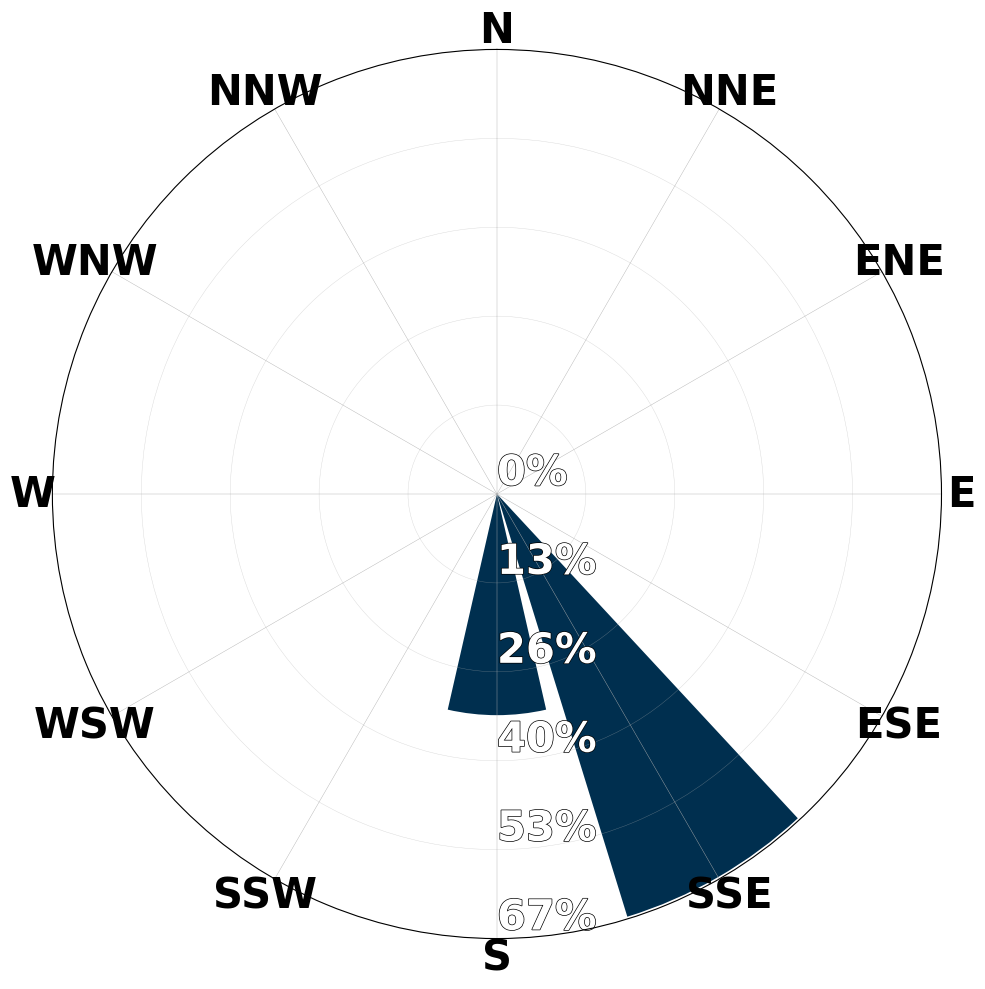

In [108]:
import pandas as pd

csfont = {'fontname':'Calibri','weight':'bold','fontsize':30}
import matplotlib.patheffects as PathEffects
dirres = 30 

dir_breaks = [-dirres/2]
dir_breaks.extend(np.arange(dirres/2, 360-dirres/2,  dirres).tolist())

dir_breaks.extend([360-dirres/2])
dir_breaks.extend([360+dirres/2])

dir_labels = ["N","NNE","ENE","E","ESE","SSE","S","SSW","WSW","W","WNW","NNW","N1"]

dir_breaks_midpoint1 = pd.Series([dir_breaks + (dirres/2) for dir_breaks in dir_breaks[:-1]])


dir_breaks_midpoint1 = pd.DataFrame({'degree':dir_breaks_midpoint1,'WindDir_bins':dir_labels})

barDir1 = pd.Series(dir_breaks[:-1]) 
barDir1 = barDir1[1:len(barDir1)]
barDir1 = pd.Series(barDir1) * np.pi/180. - np.pi/len(barDir1)
barWidth1 = 2 * np.pi / len(dir_breaks)

barDir2 = pd.Series(dir_breaks) 
barDir2 = barDir2[1:len(barDir2)]
barDir2= pd.Series(barDir2) * np.pi/180. - np.pi/len(barDir2)
barDir2[13] = barDir2[1]

wave_windrose_fig, ax = plt.subplots(1,1,figsize=(22,10), subplot_kw=dict(polar=True))

df = pd.DataFrame()

#df['speed'] = fff.iloc[:,0]
df['direction'] = mean_morning_winds['wdir_vec_mean']
        
#fff = df['direction'].value_counts() * 100
        
#bins = np.arange(0,390,30)
#labels = np.arange(0,360,30)
bins1 = np.arange(15,375,30)
lab1 = np.arange(30,345,30)
bins2 = [0,15]
bins3 = [345,360]

#labels = [0,30,60,90,120,150,180,210,240,270,300]
#df = pd.DataFrame({'Points': [0,1,350,356, 357, 359]})

ss1 =pd.cut(df['direction'], bins=bins1,labels=lab1,right=False).dropna()

ss2 = pd.cut(df['direction'], bins=bins2,labels=[0],right=False).dropna()

ss3 = pd.cut(df['direction'], bins=bins3,labels=[0],right=False).dropna()

dft_new = pd.concat([ss1,ss2,ss3])
    
#frequency =dft_new.value_counts(normalize=True)*100
#n_direc = pd.cut(df.iloc[:,0],bins=bins,labels=labels)
#frequency = n_direc.value_counts(normalize=True)*100
        
#nfreq = frequency.reset_index().reset_index(drop=True).sort_values('proportion')
frequency = dft_new.value_counts(normalize=True)*100
# Don't sort! Keep the frequencies in directional order
nfreq = frequency.sort_index().reset_index()  # Sort by direction (0, 30, 60, ..., 330)

ax.set_theta_direction('clockwise')
ax.set_theta_zero_location('N')
"""
ax.bar(barDir1, nfreq['direction'][0:12].values, 
                               width=barWidth1,
                               color = '#002F4F',
                               label="lk",
                               linewidth=0)

"""
# make the nfreqc(dataframe) as same as barDir1 by adding a zero at the end
nfreq.loc[len(nfreq)] = [360,0]

ax.bar(barDir1, nfreq['proportion'],  # Use nfreq.values directly
       width=barWidth1,
       color='#002F4F',
       label="lk",
       linewidth=0)
ax.set_xticks(barDir1)
ax.set_xticklabels(dir_labels[0:12],**csfont)  
ax.set_xticks(barDir1)  

"""
a=np.floor(nfreq['direction'].min())
b=np.ceil(nfreq['direction'].max())
x = np.linspace(a,b,6)
x=x.tolist()
x.extend([b+b/5])
x = [round(x) for x in x]
ax.set_yticks(x)
x = [str(x) + '%' for x in x]
x[len(x)-1] = ''
ax.set_yticklabels(x,**csfont)
"""
# Get the maximum frequency to set the radial limit
max_freq = np.ceil(frequency.max())

# Create evenly spaced tick marks from 0 to max frequency
yticks = np.linspace(0, max_freq, 6)  # 6 ticks gives you 5 intervals

ax.set_yticks(yticks)
ax.set_ylim(0, max_freq)  # Important: set the radial limit
ax.set_yticklabels([f'{int(val)}%' for val in yticks], **csfont)
pe = [PathEffects.withStroke(linewidth=1,
                                foreground="black")]
rlabels = ax.get_ymajorticklabels()
for label in rlabels:
    label.set_color('white')
    label.set_path_effects(pe)

#rmax = np.ceil(frequency.max() / 5) * 5
#ax.set_yticks(np.linspace(0, rmax, 5))
#ax.set_yticklabels([f'{int(v)}%' for v in np.linspace(0, rmax, 5)], **csfont)

#rmax = np.ceil(frequency.max() / 5) * 5
#ax.set_yticks(np.linspace(0, rmax, 5))
#ax.set_yticklabels([f'{int(v)}%' for v in np.linspace(0, rmax, 5)], **csfont)



ax.yaxis.grid(linewidth=3,alpha=0.5)
ax.grid(True,linewidth=0.3)
ax.set_rlabel_position(180)
#ht_lev = ad_cols[ii].split('_')[0][2:]
#ax.set_title('Wind Direction @ '+ht_lev+'m',**csfont)
plt.tight_layout()

In [110]:

out_fol= '/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/plots/'

wave_windrose_fig.savefig(f'{out_fol}{project}_figure6_morning_windrose.png',dpi=300)

findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: Font family 'Calibri' not found.
findfont: F

In [14]:
dset_sub_hourly_local = dset_sub_hourly.shift(time=10)

In [15]:
dset_sub_hourly_local

<xarray.Dataset> Size: 164kB
Dimensions:               (time: 5136)
Coordinates:
  * time                  (time) datetime64[ns] 41kB 2011-10-01 ... 2012-05-0...
Data variables:
    temp_mean             (time) float32 21kB nan nan nan ... 25.35 25.02 25.35
    rh_mean               (time) float32 21kB nan nan nan ... 92.78 95.66 92.43
    atmos_pressure        (time) float32 21kB nan nan nan ... 1.01e+03 1.01e+03
    org_precip_rate_mean  (time) float32 21kB nan nan nan nan ... 0.0 0.0 0.0
    wspd_arith_mean       (time) float32 21kB nan nan nan ... 0.481 0.3547 2.677
    wdir_vec_mean         (time) float32 21kB nan nan nan ... 212.9 177.2 211.0
Attributes: (12/31)
    command_line:                met_ingest -s twp -f C1
    process_version:             ingest-met-4.6-0.el5
    dod_version:                 met-b1-3.2
    site_id:                     twp
    facility_id:                 C1: Momote, Manus Island
    data_level:                  b1
    ...                          ...
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    zeb_platform:                twpmetC1.b1
    history:                     created by user dsmgr on machine gold at 1-O...

In [65]:
wind_speed_data = dset_sub_hourly_local

sun_dft = pd.read_csv('/Users/nalex2023/main/LSB_main/LSB_detectionv2/Datasets/sunrise_sunset_twp.csv')


wind_speed_data['sunrise_utc'] = xr.DataArray(sun_dft['sunrise(UTC)'].values,dims=('day'),
                      coords={'day':sun_dft['date']},name='sunrise_utc')


wind_speed_data['sunset_utc'] = xr.DataArray(sun_dft['sunset(UTC)'].values,dims=('day'),
                      coords={'day':sun_dft['date']},name='sunset_utc')

start = '2011-10-01'
end = '2012-05-01'

filter_1_results = pd.date_range(start=start,end=end,freq='1D').to_series()


def detect_lsb_ws_onset(wind_speed_data: xr.Dataset, day: pd.Timestamp) -> str:
    test_day = str(pd.to_datetime(day).date())
    try:
        sunrise = wind_speed_data['sunrise_utc'].sel(day=test_day).item()
        sunrise = pd.to_datetime(sunrise) + pd.Timedelta(hours=10)
    except KeyError:
        return np.nan
    sunrise_range = pd.date_range(start=sunrise+pd.Timedelta(hours=1),end=sunrise+pd.Timedelta(hours=7),freq="1h").round("1h")
    post_sunrise_data = wind_speed_data.sel(time=sunrise_range)
    if post_sunrise_data.time.size == 0:
        return np.nan
    diff_data = post_sunrise_data["wspd_arith_mean"].diff(dim="time").reindex(time=post_sunrise_data["time"])
    lsb_ws_onset = post_sunrise_data["wspd_arith_mean"][diff_data > 1.5]
    return lsb_ws_onset.time[0].dt.time.astype(str).values if lsb_ws_onset.size > 0 else np.nan



test_result_dft = pd.DataFrame(filter_1_results,columns=['datetime'])
test_result_dft['filter2']= filter_1_results.apply(lambda d: detect_lsb_ws_onset(wind_speed_data,d))


    

In [69]:
test_result_dft

,datetime,filter2
2011-10-01,2011-10-01,NaN
2011-10-02,2011-10-02,09:00:00
2011-10-03,2011-10-03,NaN
2011-10-04,2011-10-04,NaN
2011-10-05,2011-10-05,NaN
...,...,...
2012-04-27,2012-04-27,NaN
2012-04-28,2012-04-28,NaN
2012-04-29,2012-04-29,NaN
2012-04-30,2012-04-30,NaN


In [75]:
def detect_lsb_wd_condition(wind_speed_data: xr.Dataset, day: pd.Timestamp) -> str:
    min_wd = 0
    max_wd = 180
    test_day = str(pd.to_datetime(day).date())
    #try:
        #sunrise = wind_speed_data['sunrise_utc'].sel(day=test_day).values + pd.Timedelta(hours=10)
    try:
        sunrise = wind_speed_data['sunrise_utc'].sel(day=test_day).item()
        sunrise = pd.to_datetime(sunrise) + pd.Timedelta(hours=10)
    except KeyError:
        return np.nan
    sunrise_range = pd.date_range(start=sunrise+pd.Timedelta(hours=1),end=sunrise+pd.Timedelta(hours=7),freq="1h").round("1h")
    post_sunrise_data = wind_speed_data.sel(time=sunrise_range)
    if post_sunrise_data.time.size == 0:
        return np.nan
    wd_mask = (post_sunrise_data["wdir_vec_mean"] >= min_wd) & (post_sunrise_data["wdir_vec_mean"] <= max_wd)
    lsb_ws_onset = post_sunrise_data["wdir_vec_mean"][wd_mask]
    return lsb_ws_onset.time[0].dt.time.astype(str).values if lsb_ws_onset.size > 0 else np.nan

test_result_dft['filter3']= test_result_dft['datetime'].apply(lambda d: detect_lsb_wd_condition(wind_speed_data,d))

test_result_dft

,datetime,filter2,filter3
2011-10-01,2011-10-01,NaN,10:00:00
2011-10-02,2011-10-02,09:00:00,NaN
2011-10-03,2011-10-03,NaN,09:00:00
2011-10-04,2011-10-04,NaN,07:00:00
2011-10-05,2011-10-05,NaN,07:00:00
...,...,...,...
2012-04-27,2012-04-27,NaN,07:00:00
2012-04-28,2012-04-28,NaN,08:00:00
2012-04-29,2012-04-29,NaN,07:00:00
2012-04-30,2012-04-30,NaN,08:00:00


In [82]:
def filter4_prev_cond(wind_speed_data: xr.Dataset,result_dft:pd.Series) -> bool:
    if pd.isna(result_dft['filter2']):
        return False
    input_data = result_dft
    time_onset = input_data['datetime'].strftime("%Y-%m-%d") + ' ' +input_data['filter2']
    test_time = pd.to_datetime(time_onset) - pd.Timedelta(hours=1)

    wspd_diff = wind_speed_data['wspd_arith_mean'].diff(dim='time')

    wd_prev = wind_speed_data['wdir_vec_mean'].sel(time=test_time)
    ws_diff_prev = wspd_diff.sel(time=test_time)
    
    if ws_diff_prev < 1.5:
        condition1 = True
    else :
        condition1 = False

    if (wd_prev > 181):
        condition2 = True
    else:
        condition2 = False

    return (condition1 or condition2)


test_result_dft['filter4'] = test_result_dft.apply(lambda row: filter4_prev_cond(wind_speed_data,row), axis=1)
test_result_dft

,datetime,filter2,filter3,filter4
2011-10-01,2011-10-01,NaN,10:00:00,False
2011-10-02,2011-10-02,09:00:00,NaN,True
2011-10-03,2011-10-03,NaN,09:00:00,False
2011-10-04,2011-10-04,NaN,07:00:00,False
2011-10-05,2011-10-05,NaN,07:00:00,False
...,...,...,...,...
2012-04-27,2012-04-27,NaN,07:00:00,False
2012-04-28,2012-04-28,NaN,08:00:00,False
2012-04-29,2012-04-29,NaN,07:00:00,False
2012-04-30,2012-04-30,NaN,08:00:00,False


In [87]:


def detect_lsb_ws_cess(wind_speed_data: xr.Dataset, day: pd.Series) -> bool:
    test_day = str(pd.to_datetime(day).date())
    #try:
        #sunset = wind_speed_data['sunset_utc'].sel(day=test_day).values + pd.Timedelta(hours=10)
    try:
        sunset = wind_speed_data['sunset_utc'].sel(day=test_day).item()
        sunset = pd.to_datetime(sunset) + pd.Timedelta(hours=10)
    except KeyError:
        return np.nan
    sunset_range = pd.date_range(start=sunset+pd.Timedelta(hours=-1),end=sunset+pd.Timedelta(hours=+5),freq="1h").round("1h")
    post_sunset_data = wind_speed_data.sel(time=sunset_range)
    if post_sunset_data.time.size == 0:
        return np.nan
    max_sea = post_sunset_data["wspd_arith_mean"].max()
    time_max = post_sunset_data["wspd_arith_mean"].idxmax()
    return time_max.dt.time.astype(str).values if max_sea < 1.5 else np.nan

test_result_dft['cessation']= test_result_dft['datetime'].apply(lambda d: detect_lsb_ws_cess(wind_speed_data,d))

test_result_dft

,datetime,filter2,filter3,filter4,cessation,filter5
2011-10-01,2011-10-01,NaN,10:00:00,False,20:00:00,20:00:00
2011-10-02,2011-10-02,09:00:00,NaN,True,NaN,NaN
2011-10-03,2011-10-03,NaN,09:00:00,False,NaN,NaN
2011-10-04,2011-10-04,NaN,07:00:00,False,NaN,NaN
2011-10-05,2011-10-05,NaN,07:00:00,False,17:00:00,17:00:00
...,...,...,...,...,...,...
2012-04-27,2012-04-27,NaN,07:00:00,False,NaN,NaN
2012-04-28,2012-04-28,NaN,08:00:00,False,21:00:00,21:00:00
2012-04-29,2012-04-29,NaN,07:00:00,False,21:00:00,21:00:00
2012-04-30,2012-04-30,NaN,08:00:00,False,17:00:00,17:00:00


In [100]:
test_result_dft['filter5'] = ~test_result_dft['cessation'].isna()

test_result_dft

,datetime,filter2,filter3,filter4,cessation,filter5
2011-10-01,2011-10-01,NaN,10:00:00,False,20:00:00,True
2011-10-02,2011-10-02,09:00:00,NaN,True,NaN,False
2011-10-03,2011-10-03,NaN,09:00:00,False,NaN,False
2011-10-04,2011-10-04,NaN,07:00:00,False,NaN,False
2011-10-05,2011-10-05,NaN,07:00:00,False,17:00:00,True
...,...,...,...,...,...,...
2012-04-27,2012-04-27,NaN,07:00:00,False,NaN,False
2012-04-28,2012-04-28,NaN,08:00:00,False,21:00:00,True
2012-04-29,2012-04-29,NaN,07:00:00,False,21:00:00,True
2012-04-30,2012-04-30,NaN,08:00:00,False,17:00:00,True


In [106]:
def syno_filter7(wind_speed_data: xr.Dataset, result_dft: pd.Series):
    if pd.isna(result_dft['filter3']) or pd.isna(result_dft['cessation']):
        return np.nan

    time_onset = result_dft['datetime'].strftime("%Y-%m-%d") + " " + str(result_dft['filter3'])
    time_cess  = result_dft['datetime'].strftime("%Y-%m-%d") + " " + str(result_dft['cessation'])

    # slice the wind_speed_data
    lsb_period = wind_speed_data['wspd_arith_mean'].sel(time=slice(time_onset, time_cess))

    # check if slice is empty
    if lsb_period.time.size == 0:
        return np.nan

    max_wspd = lsb_period.max()
    time_max = lsb_period.idxmax()

    return False if max_wspd > 10 else True





test_result_dft_notna = test_result_dft[test_result_dft['filter5'].notna()]

test_result_dft['filter6'] = (
    test_result_dft_notna
    .apply(lambda row: syno_filter7(wind_speed_data, row), axis=1)
    .reindex(test_result_dft.index, fill_value=np.nan)
)


test_result_dft

,datetime,filter2,filter3,filter4,cessation,filter5,filter6
2011-10-01,2011-10-01,NaN,10:00:00,False,20:00:00,True,True
2011-10-02,2011-10-02,09:00:00,NaN,True,NaN,False,NaN
2011-10-03,2011-10-03,NaN,09:00:00,False,NaN,False,NaN
2011-10-04,2011-10-04,NaN,07:00:00,False,NaN,False,NaN
2011-10-05,2011-10-05,NaN,07:00:00,False,17:00:00,True,True
...,...,...,...,...,...,...,...
2012-04-27,2012-04-27,NaN,07:00:00,False,NaN,False,NaN
2012-04-28,2012-04-28,NaN,08:00:00,False,21:00:00,True,True
2012-04-29,2012-04-29,NaN,07:00:00,False,21:00:00,True,True
2012-04-30,2012-04-30,NaN,08:00:00,False,17:00:00,True,True


In [ ]:
test_result_dft_nan_removed = test_result_dft[test_result_dft['filter2'].notna()]

test_result_dft['final_tests'] = test_result_dft['filter2']

,datetime,filter2,filter3,filter4,cessation,filter5,filter6
2011-10-01,2011-10-01,NaN,10:00:00,False,20:00:00,True,True
2011-10-02,2011-10-02,09:00:00,NaN,True,NaN,False,NaN
2011-10-03,2011-10-03,NaN,09:00:00,False,NaN,False,NaN
2011-10-04,2011-10-04,NaN,07:00:00,False,NaN,False,NaN
2011-10-05,2011-10-05,NaN,07:00:00,False,17:00:00,True,True
...,...,...,...,...,...,...,...
2012-04-27,2012-04-27,NaN,07:00:00,False,NaN,False,NaN
2012-04-28,2012-04-28,NaN,08:00:00,False,21:00:00,True,True
2012-04-29,2012-04-29,NaN,07:00:00,False,21:00:00,True,True
2012-04-30,2012-04-30,NaN,08:00:00,False,17:00:00,True,True


<Axes: >

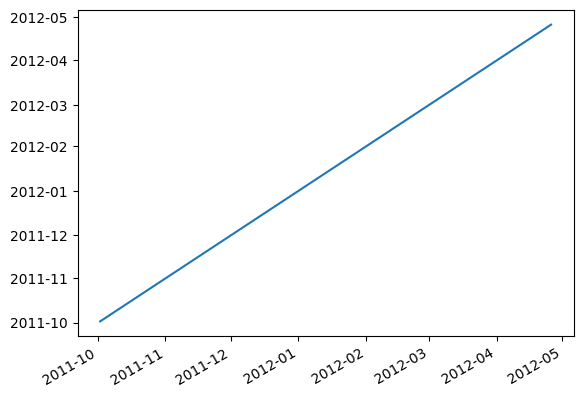

In [ ]:
fig,ax = plt.subplots()
dummy_time = pd.date_range(start='2000')
test_result_dft_nan_removed['datetime'].plot()

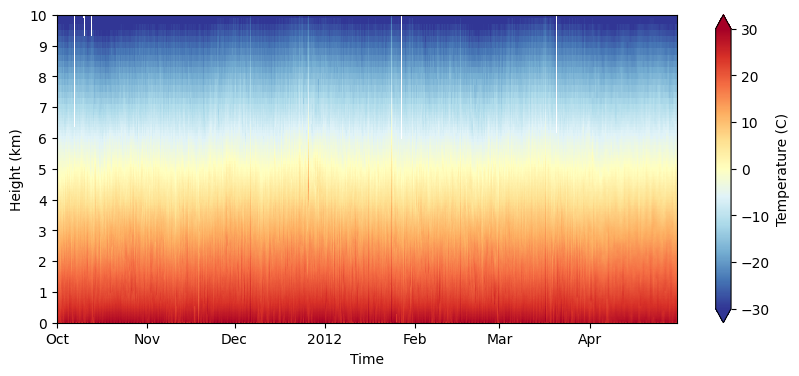

In [ ]:
fig,ax = plt.subplots(figsize=(10,4))

dset_interp_sub_hourly['temp'].plot(x='time',ax=ax,vmin=-30,vmax=30,cmap='RdYlBu_r',cbar_kwargs={'label':'Temperature (C)'})



ax.set_ylim(0,10)
ax.set_ylabel('Height (km)')
ax.set_xlabel('Time')
# y ticks every 1 km
ax.set_yticks(np.arange(0,11,1))

fig.savefig(f'{out_fol}{project}_figure3_arm_interp_temp.png',dpi=300)

fig,ax = plt.subplots(figsize=(10,4))

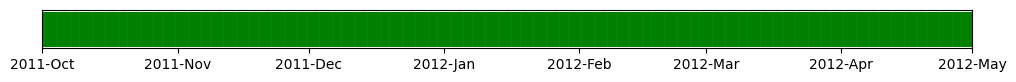

In [15]:

import matplotlib.dates as mdates

dfts = '/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/Datasets/twpmetC1.b1/arm_met_dft.csv'

df_dft = pd.read_csv(dfts,parse_dates=['datetime'])

all_dates = pd.date_range(start='2011-10-01',end='2012-05-01',freq='D')

miss_dates = pd.DatetimeIndex(df_dft['datetime']).difference(all_dates)


miss_dates_df = pd.DataFrame({'date':miss_dates,'filename':np.zeros(len(miss_dates))+10})
data_dates_df = pd.DataFrame({'date':all_dates,'filename':np.zeros(len(all_dates))+10})

fig,ax = plt.subplots(figsize=(12,0.5))



ax.vlines(data_dates_df['date'],ax.get_ylim()[0],ax.get_ylim()[1],color='g',linewidth=4)
ax.vlines(miss_dates_df['date'],ax.get_ylim()[0],ax.get_ylim()[1],color='r',linewidth=4)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))



ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))

ax.set_xlim(all_dates[0],all_dates[-1])

ax.set_yticks([])

fig.savefig(f'{out_fol}{project}_figure4_arm_met_dft_dates.png',dpi=300)


In [16]:

## seasonal plots 


dset_interp_sub_seasonal = dset_interp_sub_hourly.groupby('time.season').mean(dim='time').compute()



In [17]:
dset_interp_sub_diurnal = dset_interp_sub_hourly.groupby('time.hour').mean(dim='time').compute()

dset_interp_sub_diurnal

<xarray.Dataset> Size: 65kB
Dimensions:  (hour: 24, height: 332)
Coordinates:
  * hour     (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 15 16 17 18 19 20 21 22 23
  * height   (height) float32 1kB 0.004 0.024 0.044 0.064 ... 39.5 40.0 40.5
Data variables:
    temp     (hour, height) float32 32kB 29.1 28.71 28.41 28.16 ... nan nan nan
    rh       (hour, height) float32 32kB 72.9 70.26 72.87 75.49 ... nan nan nan
Attributes: (12/13)
    command_line:          idl -D 0 -R -n interpolatedsonde -s twp -f C1 -b 2...
    Conventions:           ARM-1.1
    process_version:       vap-interpolatedsonde-6.6-0.el6
    input_datastreams:     twpgriddedsondeC1.c0 : 2.2 : 20110929.000030-20111...
    dod_version:           interpolatedsonde-c1-4.0
    site_id:               twp
    ...                    ...
    facility_id:           C1
    data_level:            c1
    location_description:  Tropical Western Pacific (TWP), Manus Island, Papu...
    datastream:            twpinterpolatedsondeC1.c1
    doi:                   10.5439/1095316
    history:               created by user ttoto on machine silver at 2016-05...

In [27]:
temp_ano = dset_interp_sub_hourly['temp'] - dset_interp_sub_hourly['temp'].mean(dim='time')

temp_ano_diurnal = temp_ano.groupby('time.hour').mean(dim='time').compute() 

NameError: name 'temp_ano_diurnal' is not defined

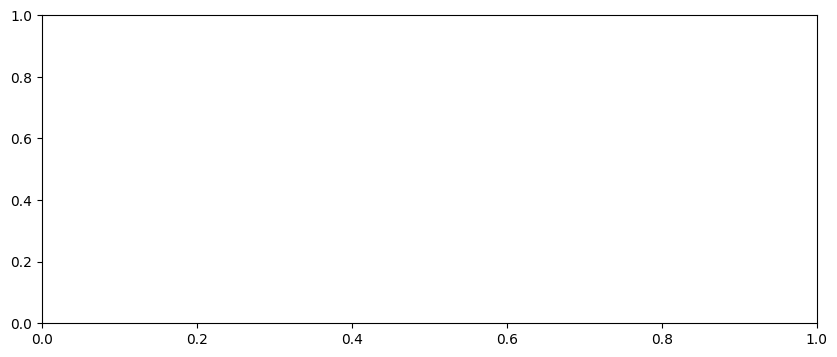

In [18]:

fig,ax = plt.subplots(figsize=(10,4))
temp_ano_diurnal.plot(x='hour', ax=ax)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Temperature (C)')


# ticks every 1 hour 
ax.set_xticks(np.arange(0,24,1))

In [35]:
import xarray as xr 
import pandas as pd 
import glob



In [37]:
dset_era = xr.open_mfdataset('/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/Datasets/ERA5_dsets/reanalysis-era5-single-levels/*.nc')

dset_era

<xarray.Dataset> Size: 498MB
Dimensions:     (valid_time: 120, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2000-01-01 ... 2000-01-05T23...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
    number      int64 8B 0
    expver      (valid_time) <U4 2kB dask.array<chunksize=(24,), meta=np.ndarray>
Data variables:
    t2m         (valid_time, latitude, longitude) float32 498MB dask.array<chunksize=(12, 361, 720), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-12-09T16:43 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:



dset_era_diurnal = dset_era['t2m'].sel(latitude=slice(3,-7),longitude=slice(140,150)).groupby('valid_time.hour').mean()



dset_era_diurnal

<xarray.DataArray 't2m' (hour: 24, latitude: 41, longitude: 41)> Size: 161kB
dask.array<stack, shape=(24, 41, 41), dtype=float32, chunksize=(1, 28, 41), chunktype=numpy.ndarray>
Coordinates:
  * hour       (hour) int64 192B 0 1 2 3 4 5 6 7 8 ... 16 17 18 19 20 21 22 23
  * latitude   (latitude) float64 328B 3.0 2.75 2.5 2.25 ... -6.5 -6.75 -7.0
  * longitude  (longitude) float64 328B 140.0 140.2 140.5 ... 149.5 149.8 150.0
    number     int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


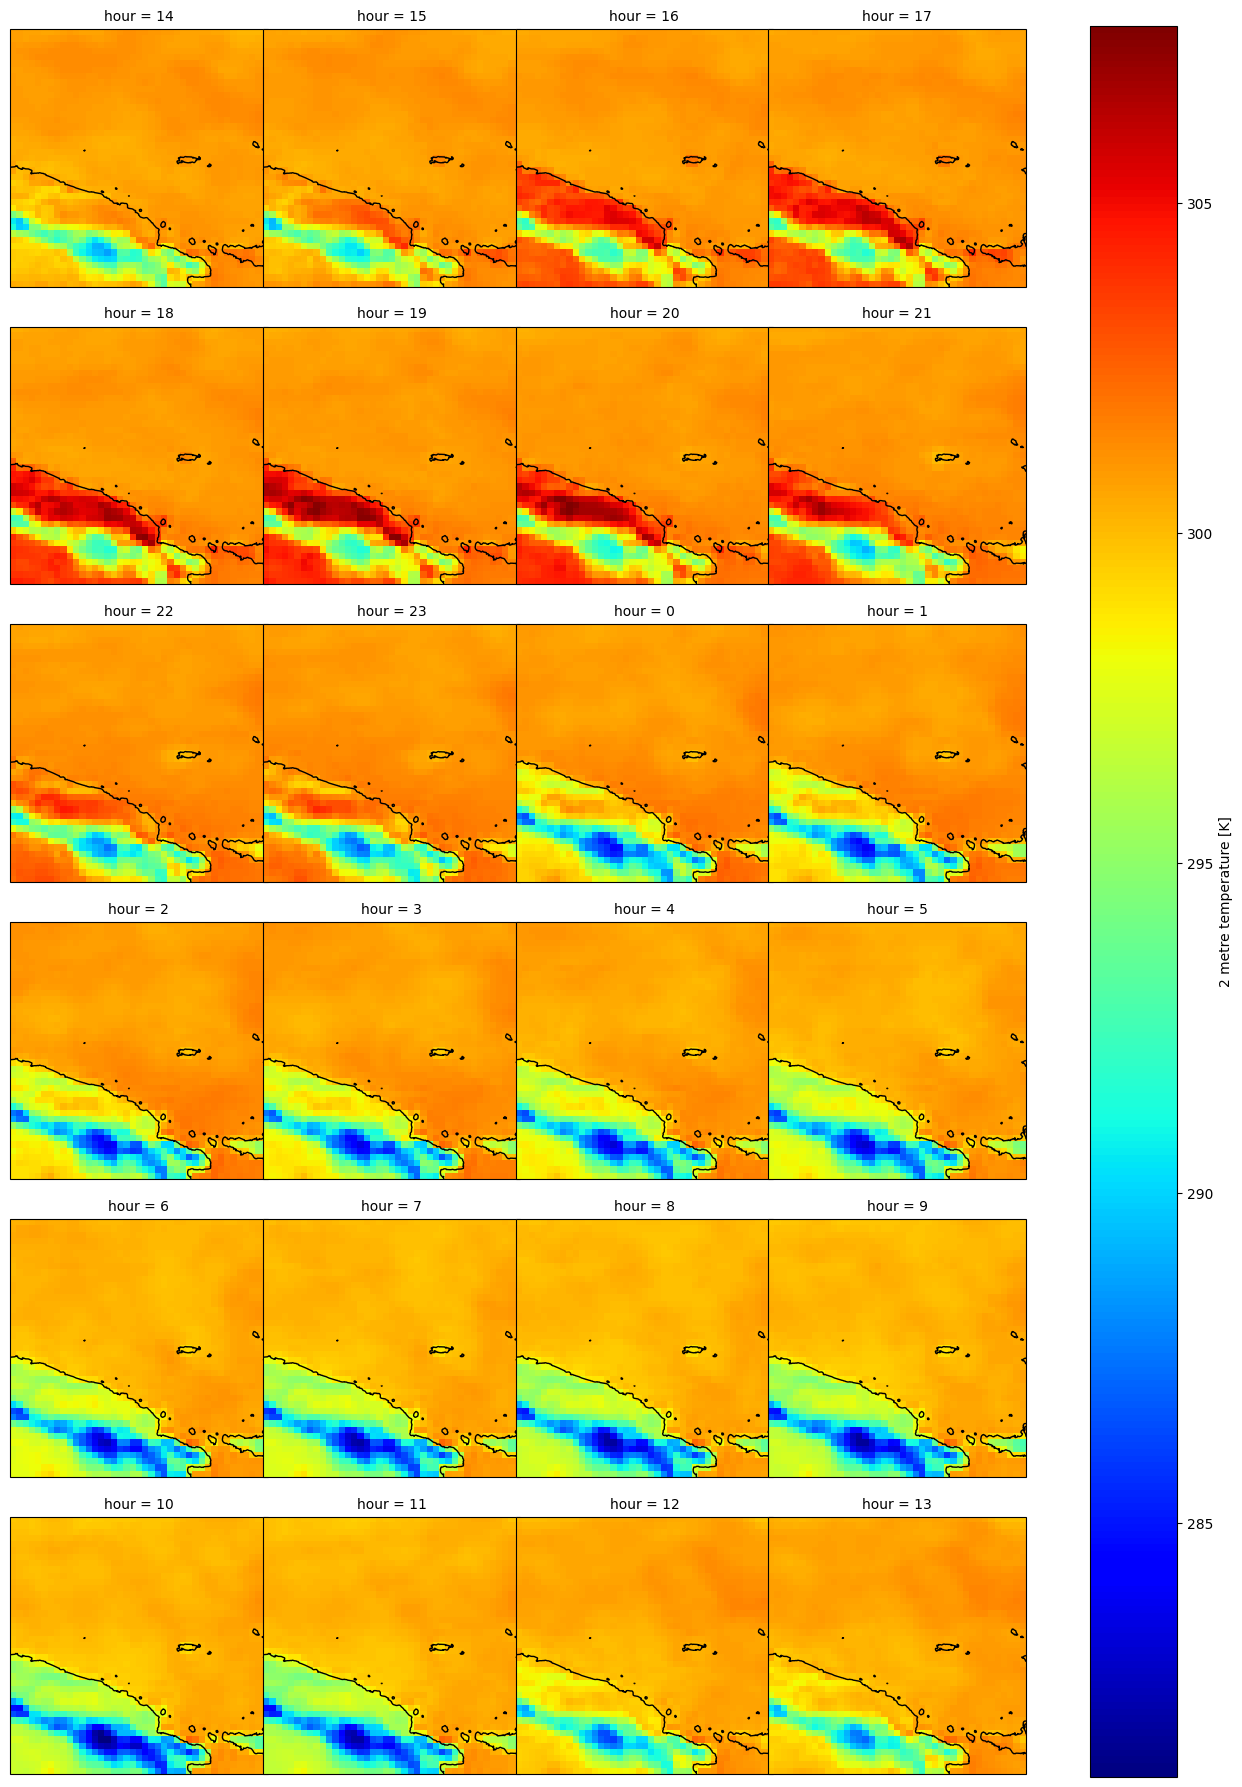

In [ ]:

import cartopy.crs as ccrs
#dset_era_diurnal.plot(x='longitude',y='latitude',col='hour',col_wrap=4,cmap='jet',)

dset_era_diurnal['hour'] = dset_era_diurnal['hour'].roll(hour=10)

g = dset_era_diurnal.plot.imshow(x= 'longitude',y='latitude',col='hour',col_wrap=4,cmap='jet',subplot_kws={"projection": ccrs.PlateCarree()})



for ax in g.axs.flat:
    ax.coastlines()
